# DEPICT Analysis 3 — Publication-Ready Plots from Saved Outputs

This notebook reads only the saved Analysis 3 compute-stage outputs and produces polished, journal-oriented figures.

**Primary figures**
- **Figure 3B:** held-out drug Hallmark pathway recovery across five drug-split folds.
- **Figure 3C:** fold-level comparison of primary drug-split and cell-split replication recovery metrics.
- **Figure 3D:** pooled class-level mechanism-panel recovery across all held-out drug-split folds.

## Important Figure 3D convention

The saved compute stage contains **drug-level signed weighted preranked enrichment scores (ES)**, not drug-level permutation-normalized enrichment scores (NES). Therefore, pooled Figure 4D uses the exact saved signed weighted GSEA-style ES values. Each eligible held-out drug contributes one observed and one predicted ES per pathway. When a drug appears in more than one held-out fold, its fold-specific drug-level ES values are averaged first, so that the inferential unit remains the drug.

The current individual-drug permutation-GSEA NES examples remain appropriate as supplementary figures.


In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
import re


In [ ]:
# ---------------------------------------------------------------------
# Paths and publication-style settings
# ---------------------------------------------------------------------
PROJECT_ROOT = Path("~/DEPICT")
MAIN_WORK_DIR = PROJECT_ROOT / "Code/downstream_analysis_code/PathwayRecovery"
OUT = MAIN_WORK_DIR / "analysis3_pathway_recovery_revised"
FIG = OUT / "figures_publication"
FIG.mkdir(parents=True, exist_ok=True)

REQUIRED = {
    "drug_units": OUT / "metrics" / "hallmark__drug_split_primary__all_unit_metrics.csv",
    "cell_units": OUT / "metrics" / "hallmark__cell_split_replication__all_unit_metrics.csv",
    "drug_null": OUT / "null" / "hallmark__drug_split_primary__all_profile_null.parquet",
    "drug_level_mechanism": OUT / "mechanism" / "mechanism_panel_drug_level_scores.csv",
    "class_bootstrap": OUT / "mechanism" / "mechanism_panel_class_level_bootstrap_ci.csv",
    "drug_classes": MAIN_WORK_DIR / "data/depict_analysis3_drug_classes.v2.csv",
}

missing = [f"{label}: {path}" for label, path in REQUIRED.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required compute-stage artifacts:\n" + "\n".join(missing))

# Restrained journal-like visual defaults. Colors are specified only for semantic groups.
mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = {
    "drug": "#2B6CB0",
    "cell": "#C05621",
    "observed": "#2F855A",
    "predicted": "#805AD5",
    "neutral": "#4A5568",
    "light_gray": "#CBD5E0",
    "dark_gray": "#2D3748",
}

# Fold colors matched exactly to Analysis1A_PublicationReady_Plots_CombinedFig3_v3.ipynb
# (Fig_A1_all_outcomes_grand). The same color is used for the corresponding
# fold number in drug_split1-5 and cell_split1-5.
FOLD_COLORS = {
    1: "#0072B2",
    2: "#E69F00",
    3: "#009E73",
    4: "#CC79A7",
    5: "#D55E00",
}

def fold_number(split_name):
    match = re.search(r"(\d+)$", str(split_name))
    if match is None:
        raise ValueError(f"Could not extract fold number from split label: {split_name}")
    return int(match.group(1))


CLASS_ORDER = ["PI3K_AKT_MTOR", "CDK", "TOPOISOMERASE", "RTK_SIGNALING"]
CLASS_LABELS = {
    "PI3K_AKT_MTOR": "PI3K–AKT–mTOR",
    "CDK": "CDK",
    "TOPOISOMERASE": "Topoisomerase",
    "RTK_SIGNALING": "RTK signaling",
}
PATHWAY_LABELS = {
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING": "PI3K–AKT–mTOR signaling",
    "HALLMARK_MTORC1_SIGNALING": "mTORC1 signaling",
    "HALLMARK_E2F_TARGETS": "E2F targets",
    "HALLMARK_G2M_CHECKPOINT": "G2/M checkpoint",
    "HALLMARK_DNA_REPAIR": "DNA repair",
    "HALLMARK_APOPTOSIS": "Apoptosis",
    "REACTOME_MAPK_FAMILY_SIGNALING_CASCADES": "MAPK family cascades",
    "REACTOME_EGFR_ERBB_FAMILY_SIGNALING": "EGFR/ERBB family signaling",
    "REACTOME_CHROMATIN_MODIFYING_ENZYMES": "Chromatin-modifying enzymes",
    "REACTOME_CHROMATIN_ORGANIZATION": "Chromatin organization",
}

rng_global = np.random.default_rng(20260629)

drug_units = pd.read_csv(REQUIRED["drug_units"])
cell_units = pd.read_csv(REQUIRED["cell_units"])
drug_null = pd.read_parquet(REQUIRED["drug_null"])
mechanism_drug = pd.read_csv(REQUIRED["drug_level_mechanism"])
class_bootstrap_saved = pd.read_csv(REQUIRED["class_bootstrap"])
drug_class_table = pd.read_csv(REQUIRED["drug_classes"])

print(f"Drug-split inference units: {len(drug_units):,}")
print(f"Cell-split inference units: {len(cell_units):,}")
print(f"Mechanism drug-fold pathway rows: {len(mechanism_drug):,}")
print(f"Figure directory: {FIG}")


Drug-split inference units: 8,605
Cell-split inference units: 45
Mechanism drug-fold pathway rows: 11,200
Figure directory: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication


In [3]:
# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def save_figure(fig, filename):
    for ext in ("pdf", "png"):
        fig.savefig(FIG / f"{filename}.{ext}", bbox_inches="tight")
    print(f"Saved: {FIG / (filename + '.pdf')}")

def bootstrap_mean_ci(values, n_boot=5000, seed=20260629):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    mean = float(np.mean(values))
    if len(values) == 1:
        return mean, mean, mean
    rng = np.random.default_rng(seed)
    means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    lo, hi = np.quantile(means, [0.025, 0.975])
    return mean, float(lo), float(hi)

def add_panel_label(ax, label):
    ax.text(
        -0.15, 1.08, label,
        transform=ax.transAxes,
        fontweight="bold",
        fontsize=14,
        va="top",
        ha="left",
    )

def lighten_axes_grid(ax, axis="y"):
    ax.grid(axis=axis, color="#E2E8F0", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)

def paired_fold_summary(frame, metric_columns):
    rows = []
    for split_type, g in frame.groupby("split_type", sort=True):
        for metric in metric_columns:
            values = g[metric].dropna().to_numpy(float)
            rows.append({
                "split_type": split_type,
                "metric": metric,
                "mean": np.mean(values) if len(values) else np.nan,
                "n_units": len(values),
            })
    return pd.DataFrame(rows)

def stable_drug_seed(*parts):
    raw = "||".join(map(str, parts)).encode("utf-8")
    return int.from_bytes(hashlib.sha256(raw).digest()[:8], "little") % (2**32 - 1)


## Figure 3B — Held-out drug pathway recovery

Each point is a held-out drug inference unit. The boxplot summarizes within-fold distributions, while the emphasized fold median shows reproducibility across the five independent drug folds.


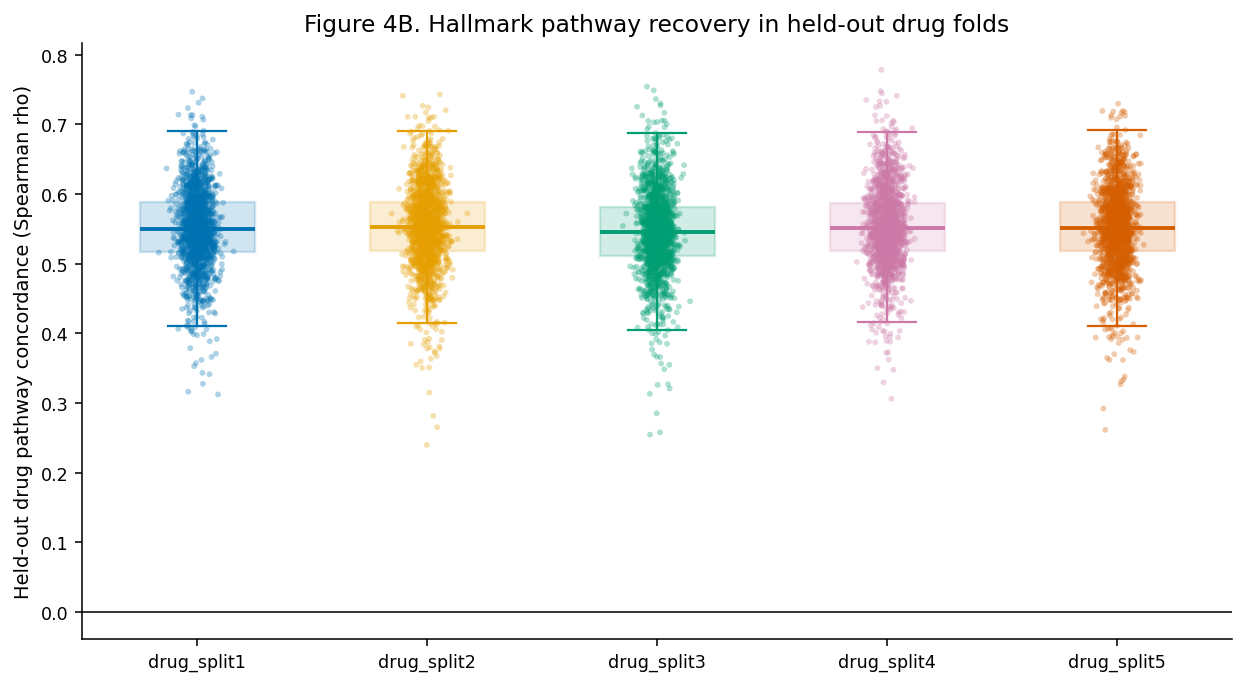

In [4]:
# Figure 4B: primary held-out drug pathway concordance.
# Fold colors are matched exactly to Fig_A1_all_outcomes_grand in Analysis 1A.
fold_order = [f"drug_split{i}" for i in range(1, 6)]
data = [
    drug_units.loc[
        drug_units["split_type"] == split,
        "pathway_profile_concordance",
    ].dropna().to_numpy()
    for split in fold_order
]

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    data,
    labels=fold_order,
    showfliers=False,
    patch_artist=True,
)

# Apply one consistent color per fold to box fill/outline, whiskers, caps,
# medians, and individual held-out-drug points.
for i, split in enumerate(fold_order):
    color = FOLD_COLORS[fold_number(split)]

    bp["boxes"][i].set(
        facecolor=color,
        edgecolor=color,
        alpha=0.18,
        linewidth=1.25,
    )
    bp["medians"][i].set(color=color, linewidth=2.0)

    for artist in bp["whiskers"][2*i:2*i+2]:
        artist.set(color=color, linewidth=1.15)
    for artist in bp["caps"][2*i:2*i+2]:
        artist.set(color=color, linewidth=1.15)

rng = np.random.default_rng(20260626)
for i, (split, values) in enumerate(zip(fold_order, data), start=1):
    color = FOLD_COLORS[fold_number(split)]
    ax.scatter(
        i + rng.normal(0, 0.04, len(values)),
        values,
        alpha=0.32,
        s=9,
        color=color,
        edgecolor="none",
        zorder=3,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Held-out drug pathway concordance (Spearman rho)")
ax.set_title("Figure 4B. Hallmark pathway recovery in held-out drug folds")

fig.tight_layout()
fig.savefig(
    FIG / "Figure4B_hallmark_drug_split_concordance.pdf",
    bbox_inches="tight",
)
plt.show()


# Fig 3B summary:

What it shows:
For each held-out drug fold, this plot shows the distribution of drug-level Spearman correlations between the observed and DEPICT-predicted Hallmark pathway-score vectors.

* Each faint point is one held-out drug.
* The boxplot summarizes the distribution within that fold.
* The darker dot is the fold median.
* The dashed horizontal line at zero represents no pathway-ranking agreement.

Interpretation:
A high rho means that in a held-out drug, pathways with relatively high observed scores also tend to have relatively high predicted scores, and pathways with relatively low observed scores also tend to have relatively low predicted scores.

A distribution clearly above zero means that, for unseen drugs, DEPICT tends to preserve the relative ordering of activated and suppressed Hallmark programs. Consistency across the five folds is especially important: it indicates that pathway recovery is reproducible across different held-out drug subsets, rather than being driven by one favorable split.

This is the main global evidence that DEPICT transfers pathway-level perturbation structure to compounds not seen during training.

## maybe next steps:
1. 

## Figure 3C — Primary drug-split versus cell-split replication

The figure summarizes the **mean metric within each fold**, not one pooled mean across all inference units. Paired fold-level points and lines retain the five-fold design and make the primary-versus-replication comparison visible without pseudo-replication.


Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication/Figure4C_primary_replication_fold_level_metrics.pdf


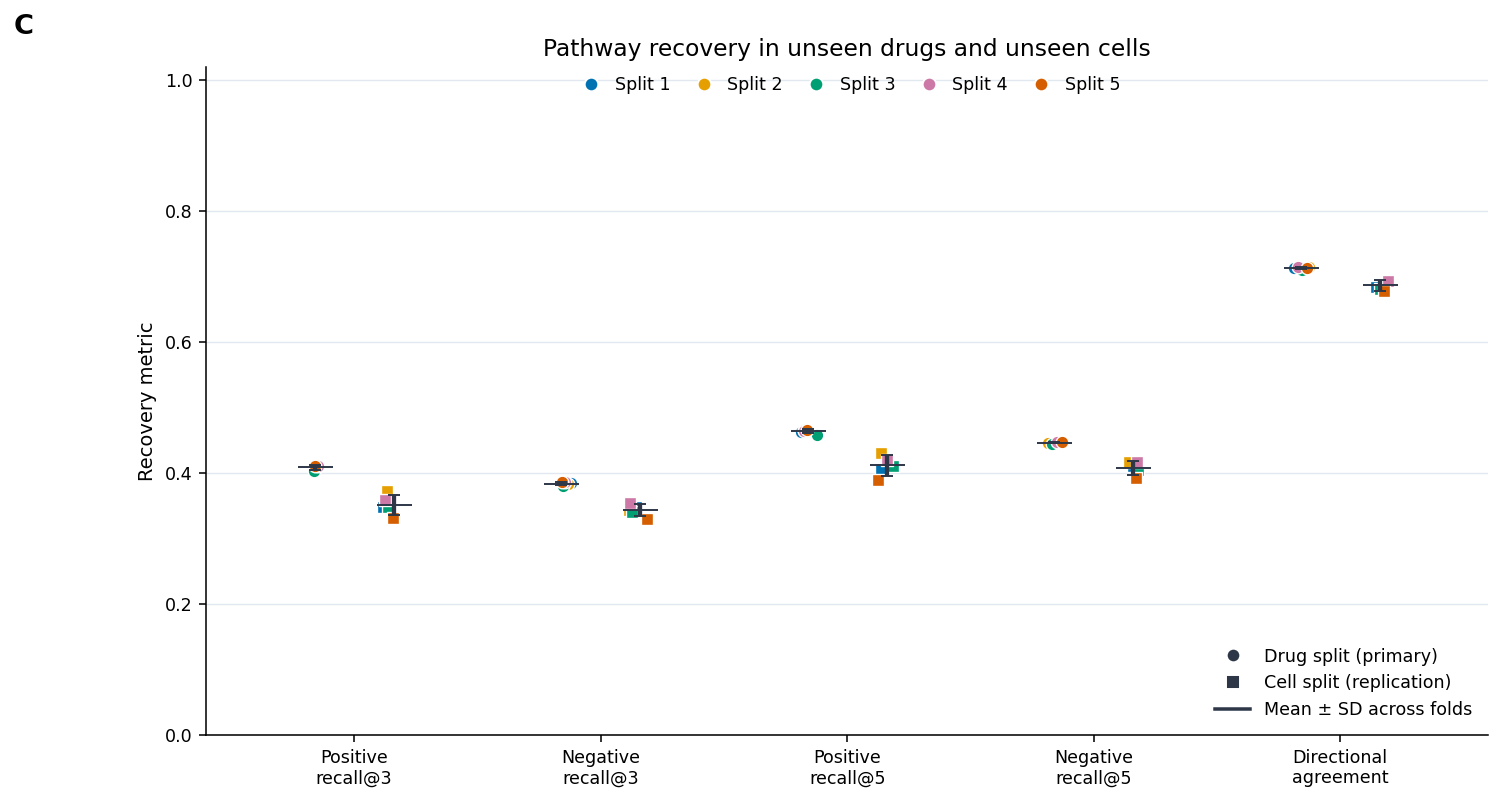

metric                              directional_agreement  negative_recall_at_3  negative_recall_at_5  positive_recall_at_3  positive_recall_at_5
analysis               split_type                                                                                                                
cell_split_replication cell_split1                 0.6838                0.3470                0.4097                0.3479                0.4064
                       cell_split2                 0.6952                0.3433                0.4160                0.3717                0.4310
                       cell_split3                 0.6814                0.3399                0.4045                0.3482                0.4100
                       cell_split4                 0.6935                0.3544                0.4172                0.3577                0.4198
                       cell_split5                 0.6773                0.3294                0.3913                0.3304                0.3888
drug_split_primary     drug_split1                 0.7128                0.3843                0.4461                0.4066                0.4626
                       drug_split2                 0.7137                0.3831                0.4456                0.4099                0.4657
                       drug_split3                 0.7102                0.3791                0.4444                0.4029                0.4581
                       drug_split4                 0.7141                0.3855                0.4472                0.4110                0.4640
                       drug_split5                 0.7124                0.3857                0.4466                0.4110                0.4655

In [5]:
# ---------------------------------------------------------------------
# Figure 4C: fold-level metric comparison, no artificial fold pairing
# Fold colors are matched exactly to Fig_A1_all_outcomes_grand in Analysis 1A.
# ---------------------------------------------------------------------
metrics = [
    "positive_recall_at_3",
    "negative_recall_at_3",
    "positive_recall_at_5",
    "negative_recall_at_5",
    "directional_agreement",
]

metric_labels = {
    "positive_recall_at_3": "Positive\nrecall@3",
    "negative_recall_at_3": "Negative\nrecall@3",
    "positive_recall_at_5": "Positive\nrecall@5",
    "negative_recall_at_5": "Negative\nrecall@5",
    "directional_agreement": "Directional\nagreement",
}

drug_fold = paired_fold_summary(drug_units, metrics).copy()
cell_fold = paired_fold_summary(cell_units, metrics).copy()

# Explicit fold ordering ensures color identity is stable and matches Analysis 1A.
drug_fold["fold_number"] = drug_fold["split_type"].map(fold_number)
cell_fold["fold_number"] = cell_fold["split_type"].map(fold_number)

fig, ax = plt.subplots(figsize=(10.7, 5.8))

x = np.arange(len(metrics))
offset_drug, offset_cell = -0.16, 0.16

for j, metric in enumerate(metrics):
    d_df = (
        drug_fold.loc[drug_fold["metric"] == metric]
        .sort_values("fold_number")
        .copy()
    )
    c_df = (
        cell_fold.loc[cell_fold["metric"] == metric]
        .sort_values("fold_number")
        .copy()
    )

    d = d_df["mean"].to_numpy(dtype=float)
    c = c_df["mean"].to_numpy(dtype=float)

    # Individual fold means.
    jitter_d = np.random.default_rng(20260700 + j).normal(0, 0.025, len(d_df))
    jitter_c = np.random.default_rng(20260800 + j).normal(0, 0.025, len(c_df))

    # Drug split = circles; cell split = squares.
    # Corresponding fold numbers use exactly the same color in both analyses.
    for k, (_, row) in enumerate(d_df.iterrows()):
        ax.scatter(
            j + offset_drug + jitter_d[k],
            row["mean"],
            s=42,
            marker="o",
            color=FOLD_COLORS[int(row["fold_number"])],
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )

    for k, (_, row) in enumerate(c_df.iterrows()):
        ax.scatter(
            j + offset_cell + jitter_c[k],
            row["mean"],
            s=42,
            marker="s",
            color=FOLD_COLORS[int(row["fold_number"])],
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )

    # Large horizontal marker = across-fold mean;
    # vertical whisker = SD across the five independent folds.
    # These summaries remain neutral so fold identity is carried only by fold colors.
    for xpos, values in [
        (j + offset_drug, d),
        (j + offset_cell, c),
    ]:
        mean_value = np.nanmean(values)
        sd_value = np.nanstd(values, ddof=1) if len(values) > 1 else 0.0

        ax.errorbar(
            xpos,
            mean_value,
            yerr=sd_value,
            fmt="_",
            markersize=18,
            color=COLORS["dark_gray"],
            linewidth=2.2,
            capsize=3,
            zorder=4,
        )

ax.set_xticks(x, [metric_labels[m] for m in metrics])
ax.set_xlim(-0.6, len(metrics) - 0.4)
ax.set_ylim(0, 1.02)
ax.set_ylabel("Recovery metric")
ax.set_title("Pathway recovery in unseen drugs and unseen cells")

lighten_axes_grid(ax)

# First legend: analysis type, encoded by marker shape.
analysis_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=COLORS["dark_gray"],
        markersize=7,
        label="Drug split (primary)",
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="w",
        markerfacecolor=COLORS["dark_gray"],
        markersize=7,
        label="Cell split (replication)",
    ),
    Line2D(
        [0], [0],
        color=COLORS["dark_gray"],
        marker="_",
        markersize=13,
        linewidth=1.8,
        label="Mean ± SD across folds",
    ),
]
legend_analysis = ax.legend(
    handles=analysis_handles,
    frameon=False,
    loc="lower right",
    title=None,
)
ax.add_artist(legend_analysis)

# Second legend: exact fold colors from Analysis 1A.
fold_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=FOLD_COLORS[i],
        markeredgecolor="white",
        markersize=7,
        label=f"Split {i}",
    )
    for i in range(1, 6)
]
ax.legend(
    handles=fold_handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
    handletextpad=0.35,
    columnspacing=0.9,
)

add_panel_label(ax, "C")

fig.tight_layout()
save_figure(fig, "Figure4C_primary_replication_fold_level_metrics")
plt.show()

fig4c_fold_table = pd.concat(
    [
        drug_fold.assign(analysis="drug_split_primary"),
        cell_fold.assign(analysis="cell_split_replication"),
    ],
    ignore_index=True,
)

display(
    fig4c_fold_table
    .pivot_table(
        index=["analysis", "split_type"],
        columns="metric",
        values="mean",
    )
    .round(4)
)

fig4c_fold_table.to_csv(
    FIG / "Figure4C_fold_level_metric_values.csv",
    index=False,
)


# Fig 3C summary:
What it shows:
This compares five pathway-recovery metrics between:

* Drug split: generalization to unseen compounds; the primary analysis.
* Cell split: generalization to unseen cellular contexts; the replication analysis.

For each metric:

* Colored small points are the five fold-level means.
* The larger horizontal marker is the mean across folds.
* The vertical whisker is the standard deviation across folds.

The metrics are:

* Positive recall@3: recovery of the three most positively enriched observed pathways.
* Negative recall@3: recovery of the three most negatively enriched observed pathways.
* Positive recall@5 / negative recall@5: the corresponding top-five recovery.
* Directional agreement: proportion of pathways for which observed and predicted enrichment have the same sign.

Interpretation:
This figure asks two separate questions:

1. Can the model identify the most strongly activated or suppressed pathways?
2. Can the model at least recover whether pathways move up or down?

Typically, directional agreement should be higher than top-k recall. That means DEPICT can often recover the broad pathway response direction even when the exact ranking among the most extreme pathways differs.

When drug-split performance is higher than cell-split performance, the interpretation is that unseen cellular background remains harder than unseen drug chemistry. That is biologically reasonable because cell state strongly shapes transcriptional response.

## maybe next steps:
1. what is the directional agreement, explain more about how we calculated this. abs(observed_ES) >= 0.20; sign(predicted_ES) == sign(observed_ES); Directional agreement=
strong observed pathways with matching predicted sign /
strong observed pathways


Does the results now indicated that DEPICT can predict the right direction for ~70% pathways?

## Figure 3D — Pooled class-level mechanism recovery across all held-out drug folds

For every eligible drug, profiles were first averaged within `split_type × pert_iname`, yielding one observed and one predicted pathway score per drug-fold. To avoid treating repeat appearances as independent evidence, any repeated drug across held-out folds is collapsed to one drug-level ES before pooling by class.

The plot displays mean signed weighted preranked ES with **95% bootstrap confidence intervals across drugs**. Thin lines connect observed and predicted values for the same pathway; they are descriptive, not paired hypothesis tests.


In [6]:
# ---------------------------------------------------------------------
# Construct one independent contribution per drug for pooled Figure 4D.
# ---------------------------------------------------------------------
required_mech_cols = {"split_type", "pert_iname", "drug_class", "pathway", "source", "es"}
missing_mech_cols = required_mech_cols - set(mechanism_drug.columns)
if missing_mech_cols:
    raise ValueError(f"Mechanism drug-level file is missing columns: {sorted(missing_mech_cols)}")

pooled_input = mechanism_drug.copy()
pooled_input = pooled_input.loc[
    pooled_input["split_type"].str.startswith("drug_split", na=False)
    & pooled_input["drug_class"].isin(CLASS_ORDER)
].copy()

# Audit whether a held-out drug appears in more than one drug split.
drug_fold_audit = (
    pooled_input[["pert_iname", "drug_class", "split_type"]]
    .drop_duplicates()
    .groupby(["pert_iname", "drug_class"], as_index=False)
    .agg(
        n_heldout_folds=("split_type", "nunique"),
        heldout_folds=("split_type", lambda x: "|".join(sorted(set(x)))),
    )
    .sort_values(["n_heldout_folds", "drug_class", "pert_iname"], ascending=[False, True, True])
)

print("Held-out-fold multiplicity per drug:")
print(drug_fold_audit["n_heldout_folds"].value_counts().sort_index().to_string())

repeat_drugs = drug_fold_audit.loc[drug_fold_audit["n_heldout_folds"] > 1]
print(f"Drugs appearing in >1 held-out drug split: {len(repeat_drugs):,}")
if len(repeat_drugs):
    display(repeat_drugs.head(30))

# Collapse repeat drug-fold ES values to exactly one contribution per drug/pathway/source.
pooled_drug_es = (
    pooled_input
    .groupby(["pert_iname", "drug_class", "pathway", "source"], as_index=False)
    .agg(
        es=("es", "mean"),
        n_heldout_folds=("split_type", "nunique"),
        n_drug_fold_rows=("split_type", "size"),
    )
)

# Cross-check that source pairing is complete for every drug/pathway.
source_counts = (
    pooled_drug_es
    .groupby(["pert_iname", "drug_class", "pathway"], as_index=False)
    .agg(n_sources=("source", "nunique"))
)
if not (source_counts["n_sources"] == 2).all():
    bad = source_counts.loc[source_counts["n_sources"] != 2]
    raise ValueError(
        "Some drug/pathway records are missing observed or predicted ES. "
        f"Examples:\n{bad.head(20).to_string(index=False)}"
    )

pooled_drug_es.to_csv(FIG / "Figure4D_pooled_drug_level_ES.csv", index=False)
drug_fold_audit.to_csv(FIG / "Figure4D_drug_fold_multiplicity_audit.csv", index=False)

print("\nPooled independent drug counts by class:")
print(
    pooled_drug_es[["pert_iname", "drug_class"]]
    .drop_duplicates()["drug_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_string()
)


Held-out-fold multiplicity per drug:
n_heldout_folds
1    29
2     8
3     1
Drugs appearing in >1 held-out drug split: 9


,pert_iname,drug_class,n_heldout_folds,heldout_folds
21,dovitinib,RTK_SIGNALING,3,drug_split1|drug_split3|drug_split5
6,JNJ-7706621,CDK,2,drug_split2|drug_split4
12,Ro-3306,CDK,2,drug_split4|drug_split5
11,PP242,PI3K_AKT_MTOR,2,drug_split4|drug_split5
33,temsirolimus,PI3K_AKT_MTOR,2,drug_split1|drug_split2
34,torin-1,PI3K_AKT_MTOR,2,drug_split2|drug_split5
19,brivanib,RTK_SIGNALING,2,drug_split2|drug_split5
36,tyrphostin-AG-18,RTK_SIGNALING,2,drug_split1|drug_split2
26,irinotecan,TOPOISOMERASE,2,drug_split2|drug_split4



Pooled independent drug counts by class:
drug_class
PI3K_AKT_MTOR    10
CDK               5
TOPOISOMERASE     7
RTK_SIGNALING    16


In [7]:
# ---------------------------------------------------------------------
# Compute pooled class-level means and bootstrap confidence intervals.
# ---------------------------------------------------------------------
summary_rows = []

for (drug_class, pathway, source), g in pooled_drug_es.groupby(
    ["drug_class", "pathway", "source"],
    sort=True,
):
    mean_es, lo, hi = bootstrap_mean_ci(
        g["es"].to_numpy(float),
        n_boot=5000,
        seed=stable_drug_seed("pooled_fig4d", drug_class, pathway, source),
    )
    summary_rows.append({
        "drug_class": drug_class,
        "pathway": pathway,
        "source": source,
        "n_drugs": g["pert_iname"].nunique(),
        "mean_es": mean_es,
        "ci95_low": lo,
        "ci95_high": hi,
    })

pooled_class_summary = pd.DataFrame(summary_rows)

# Retain pathway order from the curated mechanism panel when possible.
observed_pathway_order = (
    pooled_class_summary["pathway"]
    .drop_duplicates()
    .tolist()
)
pathway_order = [
    p for p in PATHWAY_LABELS if p in observed_pathway_order
] + [
    p for p in observed_pathway_order if p not in PATHWAY_LABELS
]

pooled_class_summary["pathway_label"] = pooled_class_summary["pathway"].map(PATHWAY_LABELS).fillna(
    pooled_class_summary["pathway"]
)
pooled_class_summary.to_csv(FIG / "Figure4D_pooled_class_ES_bootstrap_summary.csv", index=False)

display(
    pooled_class_summary
    .pivot_table(
        index=["drug_class", "pathway_label"],
        columns="source",
        values=["mean_es", "n_drugs"],
    )
    .round(4)
)


mean_es            n_drugs          
source                                    observed predicted observed predicted
drug_class    pathway_label                                                    
CDK           Apoptosis                    -0.0027    0.0790      5.0       5.0
              Chromatin organization       -0.1456   -0.0906      5.0       5.0
              Chromatin-modifying enzymes  -0.1323   -0.1088      5.0       5.0
              DNA repair                   -0.1549   -0.2004      5.0       5.0
              E2F targets                  -0.2734   -0.2679      5.0       5.0
              EGFR/ERBB family signaling    0.0055    0.0296      5.0       5.0
              G2/M checkpoint              -0.3208   -0.2977      5.0       5.0
              MAPK family cascades         -0.0315    0.0195      5.0       5.0
              PI3K–AKT–mTOR signaling      -0.0730   -0.0194      5.0       5.0
              mTORC1 signaling             -0.1395   -0.0783      5.0       5.0
PI3K_AKT_MTOR Apoptosis                     0.0896    0.1330     10.0      10.0
              Chromatin organization       -0.0737   -0.0804     10.0      10.0
              Chromatin-modifying enzymes  -0.0717   -0.0825     10.0      10.0
              DNA repair                   -0.1212   -0.1852     10.0      10.0
              E2F targets                  -0.1742   -0.2827     10.0      10.0
              EGFR/ERBB family signaling    0.1002    0.1288     10.0      10.0
              G2/M checkpoint              -0.1917   -0.2946     10.0      10.0
              MAPK family cascades          0.0965    0.1021     10.0      10.0
              PI3K–AKT–mTOR signaling      -0.0142    0.0341     10.0      10.0
              mTORC1 signaling             -0.1011   -0.1827     10.0      10.0
RTK_SIGNALING Apoptosis                     0.0430    0.0756     16.0      16.0
              Chromatin organization       -0.0495   -0.0504     16.0      16.0
              Chromatin-modifying enzymes  -0.0431   -0.0670     16.0      16.0
              DNA repair                   -0.0564   -0.0955     16.0      16.0
              E2F targets                  -0.0877   -0.1603     16.0      16.0
              EGFR/ERBB family signaling    0.0224    0.0521     16.0      16.0
              G2/M checkpoint              -0.1082   -0.1774     16.0      16.0
              MAPK family cascades          0.0048    0.0279     16.0      16.0
              PI3K–AKT–mTOR signaling       0.0264    0.0411     16.0      16.0
              mTORC1 signaling              0.0170    0.0100     16.0      16.0
TOPOISOMERASE Apoptosis                     0.1320    0.0811      7.0       7.0
              Chromatin organization       -0.1301   -0.1271      7.0       7.0
              Chromatin-modifying enzymes  -0.1499   -0.1620      7.0       7.0
              DNA repair                    0.0386   -0.1291      7.0       7.0
              E2F targets                  -0.2371   -0.3364      7.0       7.0
              EGFR/ERBB family signaling   -0.0259    0.0365      7.0       7.0
              G2/M checkpoint              -0.3332   -0.3784      7.0       7.0
              MAPK family cascades         -0.0151    0.0044      7.0       7.0
              PI3K–AKT–mTOR signaling       0.0915   -0.0140      7.0       7.0
              mTORC1 signaling             -0.0937   -0.1314      7.0       7.0

Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication/Figure4D_pooled_class_mechanism_recovery.pdf


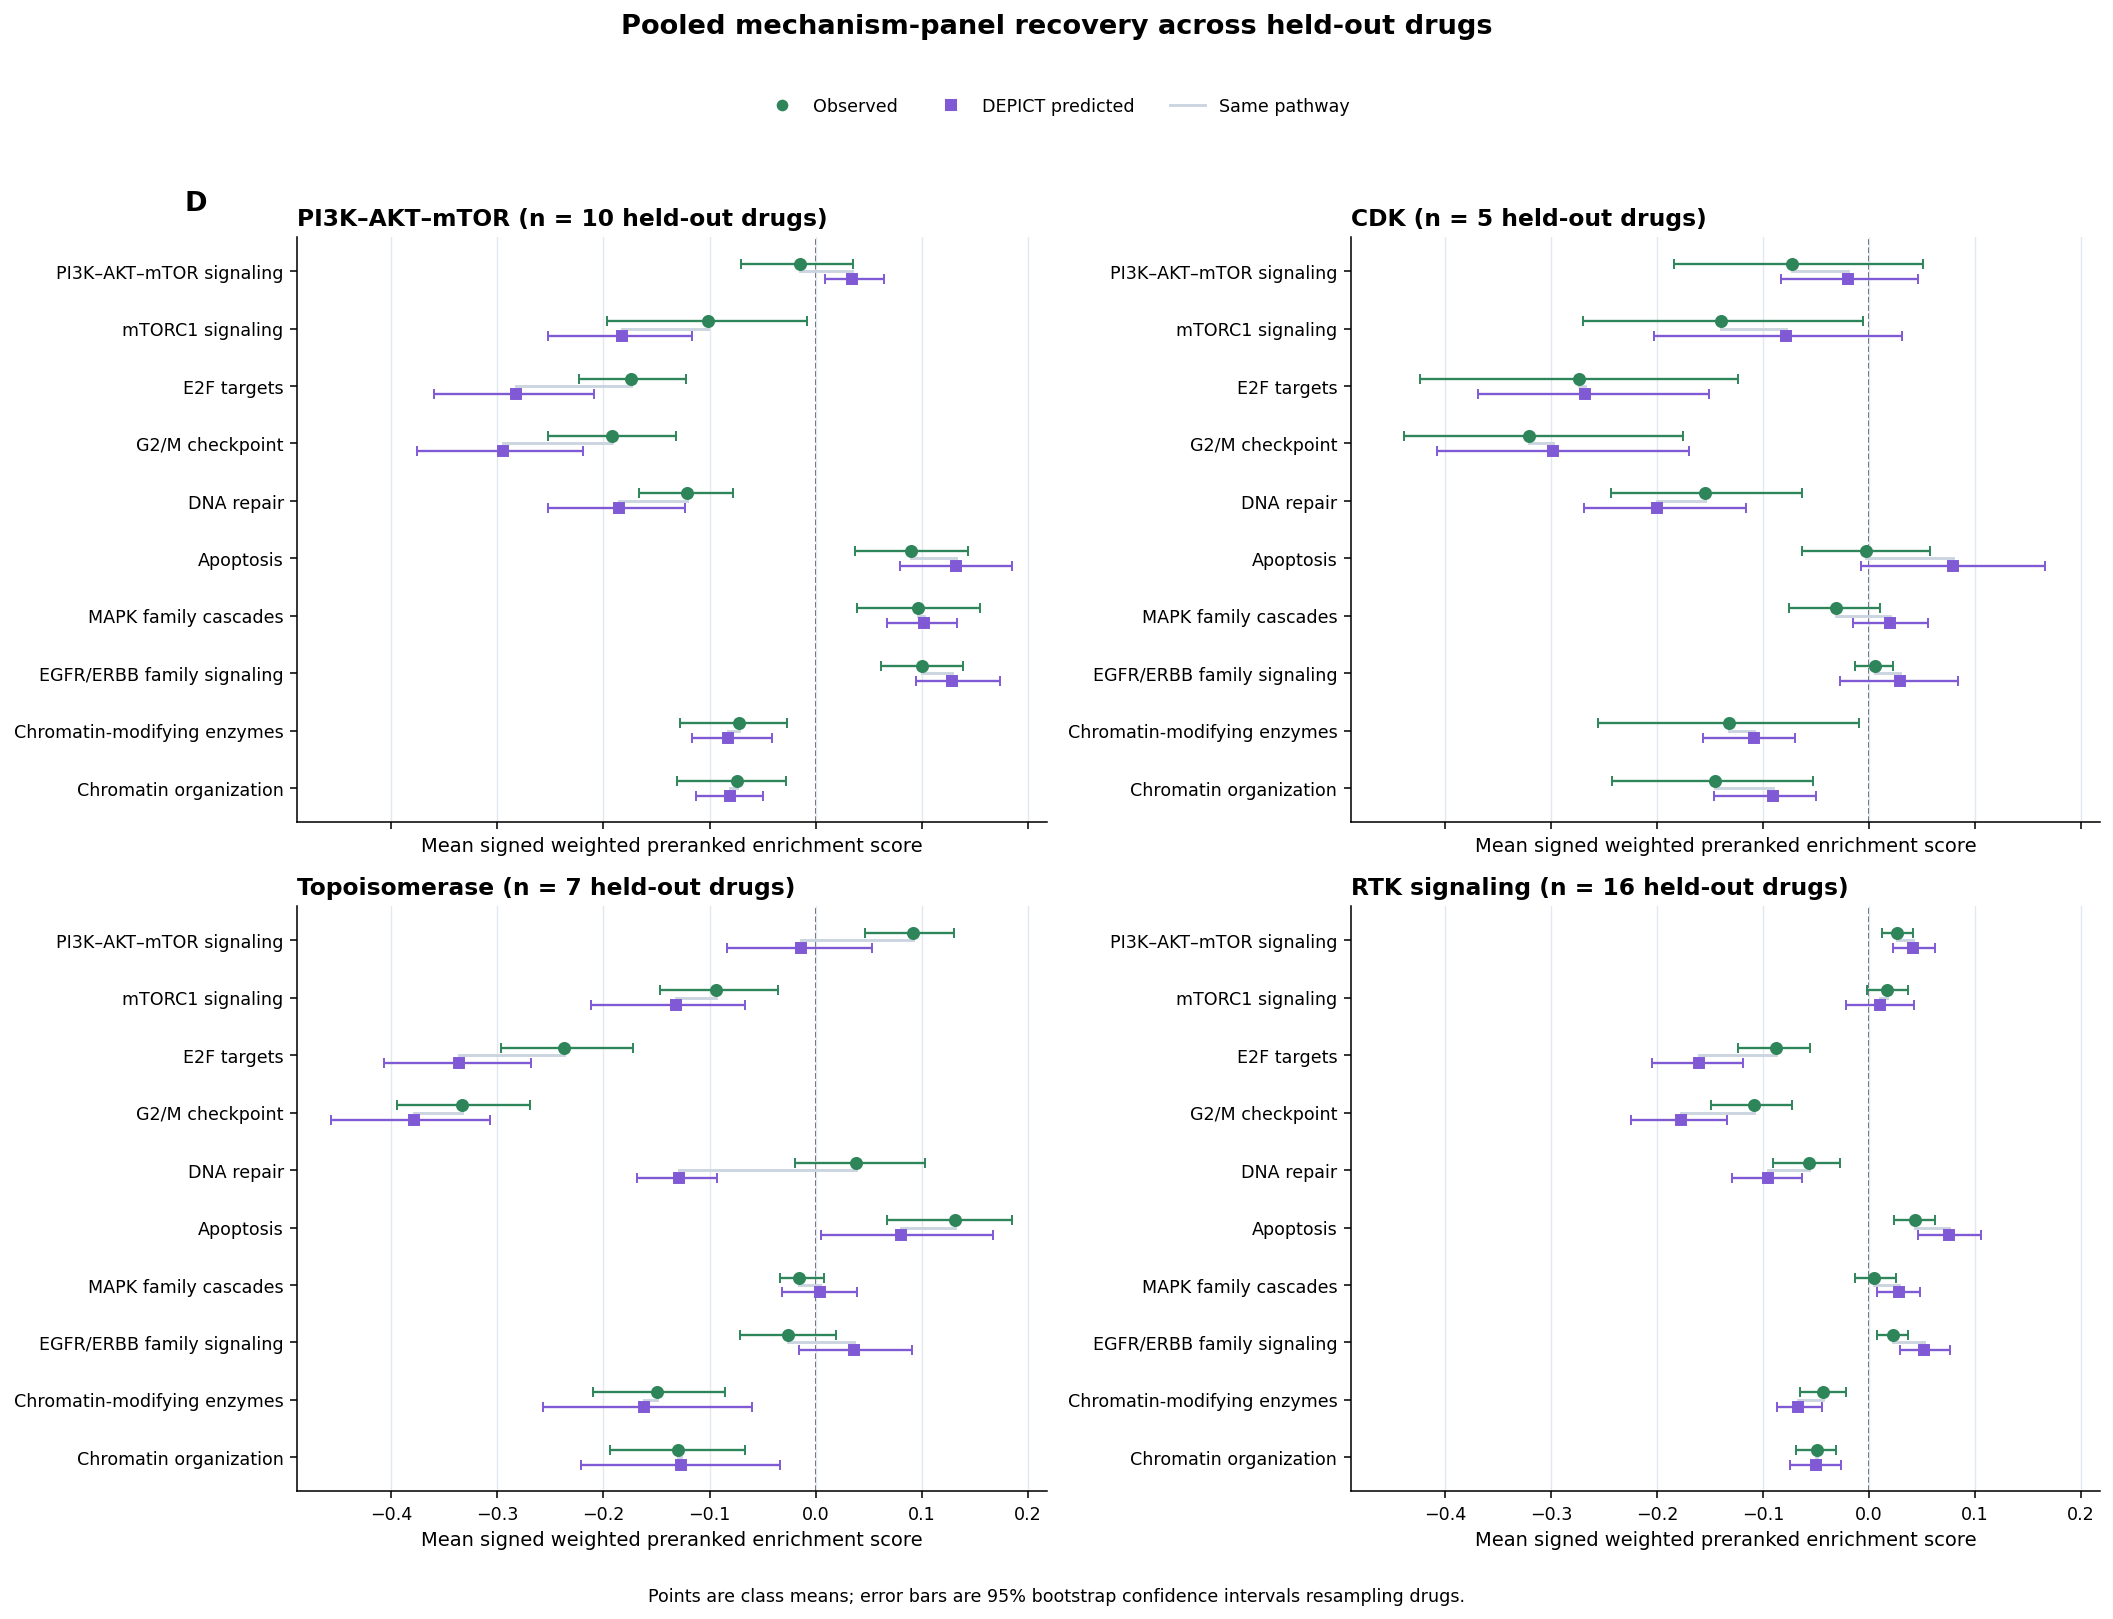

In [8]:
# ---------------------------------------------------------------------
# Figure 4D: pooled class-level observed versus predicted signed ES.
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15.2, 10.8), sharex=True)
axes = axes.ravel()

for ax, drug_class, panel_letter in zip(axes, CLASS_ORDER, ["D", "", "", ""]):
    panel = pooled_class_summary.loc[
        pooled_class_summary["drug_class"] == drug_class
    ].copy()

    # Keep only pathways with both observed and predicted values.
    wide = (
        panel.pivot(index="pathway", columns="source", values=["mean_es", "ci95_low", "ci95_high", "n_drugs"])
        .reindex(pathway_order)
        .dropna(subset=[("mean_es", "observed"), ("mean_es", "predicted")])
    )

    if wide.empty:
        ax.text(0.5, 0.5, f"No pooled data for {drug_class}", ha="center", va="center")
        ax.axis("off")
        continue

    y = np.arange(len(wide))
    obs_mean = wide[("mean_es", "observed")].to_numpy(float)
    pred_mean = wide[("mean_es", "predicted")].to_numpy(float)
    obs_lo = wide[("ci95_low", "observed")].to_numpy(float)
    obs_hi = wide[("ci95_high", "observed")].to_numpy(float)
    pred_lo = wide[("ci95_low", "predicted")].to_numpy(float)
    pred_hi = wide[("ci95_high", "predicted")].to_numpy(float)

    # Pathway-specific observed-to-predicted connecting segments.
    for yy, obs, pred in zip(y, obs_mean, pred_mean):
        ax.plot([obs, pred], [yy, yy], color=COLORS["light_gray"], linewidth=1.5, zorder=1)

    ax.errorbar(
        obs_mean, y - 0.13,
        xerr=np.vstack([obs_mean - obs_lo, obs_hi - obs_mean]),
        fmt="o",
        color=COLORS["observed"],
        ecolor=COLORS["observed"],
        elinewidth=1.2,
        capsize=2.5,
        markersize=5.7,
        label="Observed",
        zorder=3,
    )
    ax.errorbar(
        pred_mean, y + 0.13,
        xerr=np.vstack([pred_mean - pred_lo, pred_hi - pred_mean]),
        fmt="s",
        color=COLORS["predicted"],
        ecolor=COLORS["predicted"],
        elinewidth=1.2,
        capsize=2.5,
        markersize=5.2,
        label="DEPICT predicted",
        zorder=3,
    )

    ax.axvline(0, color=COLORS["dark_gray"], linewidth=0.8, linestyle="--", zorder=0)
    ax.set_yticks(y)
    ax.set_yticklabels([PATHWAY_LABELS.get(p, p) for p in wide.index])
    ax.invert_yaxis()
    n_drugs = int(wide[("n_drugs", "observed")].iloc[0])
    ax.set_title(f"{CLASS_LABELS[drug_class]} (n = {n_drugs} held-out drugs)", loc="left", fontweight="bold")
    ax.set_xlabel("Mean signed weighted preranked enrichment score")
    lighten_axes_grid(ax, axis="x")

    if panel_letter:
        add_panel_label(ax, panel_letter)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["observed"], markersize=7, label="Observed"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=COLORS["predicted"], markersize=7, label="DEPICT predicted"),
    Line2D([0], [0], color=COLORS["light_gray"], linewidth=1.5, label="Same pathway"),
]
fig.legend(
    handles=handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
)
fig.suptitle(
    "Pooled mechanism-panel recovery across held-out drugs",
    y=1.055,
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.5,
    0.005,
    "Points are class means; error bars are 95% bootstrap confidence intervals resampling drugs.",
    ha="center",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.025, 1, 0.98])
save_figure(fig, "Figure4D_pooled_class_mechanism_recovery")
plt.show()


# Fig 3D Summary:
Interpretation:
Figure 4D asks:

Across an entire drug mechanism class, does DEPICT reproduce the observed pathway-response pattern?

Strong agreement appears when observed and predicted points:

* fall on the same side of zero;
* have similar magnitude;
* have overlapping or nearby confidence intervals;
* show short gray connecting segments.

For example:

* In the CDK panel, concordant E2F and G2/M effects would support recovery of expected cell-cycle programs.
* In the RTK signaling panel, agreement for EGFR/ERBB and MAPK programs supports recovery of receptor-tyrosine-kinase-associated downstream responses.
* In the PI3K–AKT–mTOR panel, agreement for PI3K–AKT–mTOR and mTORC1 pathways would support class-level pathway recovery.
* In the topoisomerase panel, agreement in DNA repair, cell-cycle, apoptosis, or chromatin-related programs would indicate that DEPICT captures shared downstream stress-response biology.

The key advantage over the former individual-drug Figure 4D is that this is no longer anecdotal. It supports a class-level claim.

## Maybe Next Steps:


## Supplementary quality-control and interpretability plots

These are not required as main Figure 4 panels, but they are useful for manuscript development and reviewer-facing supplements:
- matched random-drug null gain by fold;
- class-level observed–predicted ES correlation across pathways;
- individual drug-level mechanism recovery distributions.


Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication/Supplement_matched_random_drug_null_gain_by_fold.pdf


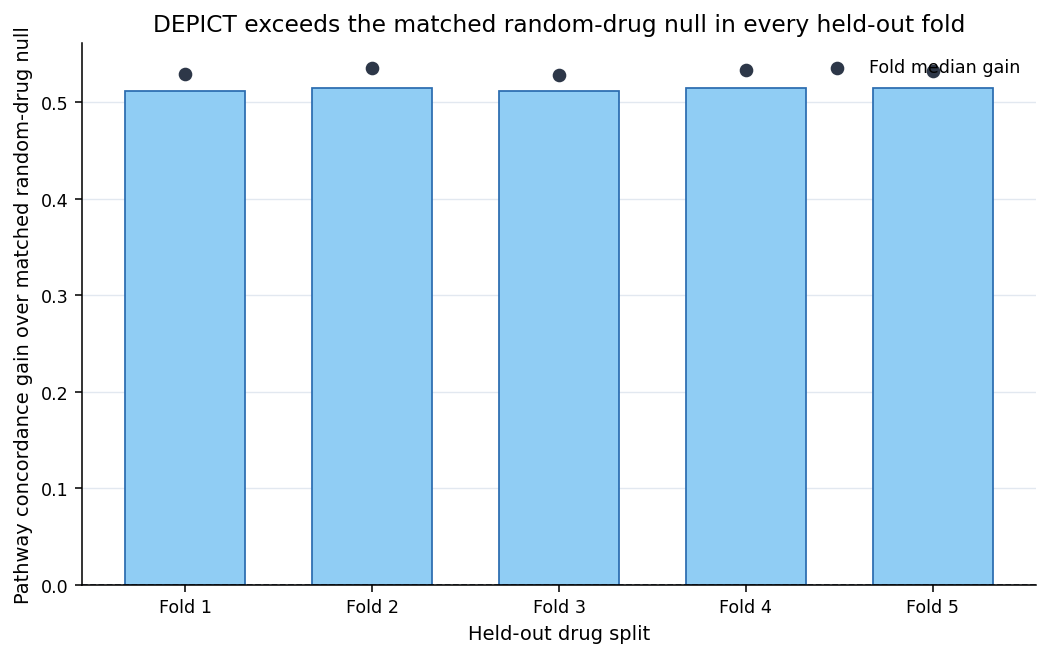

,split_type,mean_gain,median_gain,n_profiles,eligible_fraction,fold_number
0,drug_split1,0.5112,0.5295,85195,1.0,1
1,drug_split2,0.5151,0.5350,86432,1.0,2
2,drug_split3,0.5114,0.5288,77732,1.0,3
3,drug_split4,0.5150,0.5338,76723,1.0,4
4,drug_split5,0.5149,0.5329,79591,1.0,5


In [9]:
# ---------------------------------------------------------------------
# Supplement: matched random-drug null gain by fold.
# ---------------------------------------------------------------------
null_plot = (
    drug_null.dropna(subset=["gain"])
    .groupby("split_type", as_index=False)
    .agg(
        mean_gain=("gain", "mean"),
        median_gain=("gain", "median"),
        n_profiles=("gain", "size"),
        eligible_fraction=(
            "candidate_pool_size",
            lambda x: np.mean(np.asarray(x) >= 2),
        ),
    )
)

# Extract the trailing fold number from labels such as drug_split1.
null_plot["fold_number"] = pd.to_numeric(
    null_plot["split_type"].astype(str).str.extract(r"(\d+)$")[0],
    errors="coerce",
)

if null_plot["fold_number"].isna().any():
    bad_labels = (
        null_plot.loc[
            null_plot["fold_number"].isna(),
            "split_type",
        ]
        .drop_duplicates()
        .tolist()
    )
    raise ValueError(
        f"Could not extract fold numbers from these split labels: {bad_labels}"
    )

null_plot["fold_number"] = null_plot["fold_number"].astype(int)
null_plot = null_plot.sort_values("fold_number").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.6, 4.8))

x = np.arange(len(null_plot))

ax.bar(
    x,
    null_plot["mean_gain"],
    width=0.64,
    color="#90CDF4",
    edgecolor=COLORS["drug"],
    linewidth=0.9,
    zorder=2,
)

ax.scatter(
    x,
    null_plot["median_gain"],
    color=COLORS["dark_gray"],
    s=36,
    zorder=3,
    label="Fold median gain",
)

ax.axhline(
    0,
    color=COLORS["dark_gray"],
    linewidth=0.8,
    linestyle="--",
)

ax.set_xticks(x, [f"Fold {n}" for n in null_plot["fold_number"]])
ax.set_xlabel("Held-out drug split")
ax.set_ylabel("Pathway concordance gain over matched random-drug null")
ax.set_title("DEPICT exceeds the matched random-drug null in every held-out fold")

lighten_axes_grid(ax)
ax.legend(frameon=False)

fig.tight_layout()
save_figure(fig, "Supplement_matched_random_drug_null_gain_by_fold")
plt.show()

display(null_plot.round(4))

null_plot.to_csv(
    FIG / "Supplement_null_gain_by_fold.csv",
    index=False,
)

,drug_class,n_pathways,spearman_rho_across_pathways
0,PI3K_AKT_MTOR,10,0.9515
1,CDK,10,0.9515
2,TOPOISOMERASE,10,0.8303
3,RTK_SIGNALING,10,0.9636


Saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication/Supplement_pooled_class_pathway_concordance.pdf


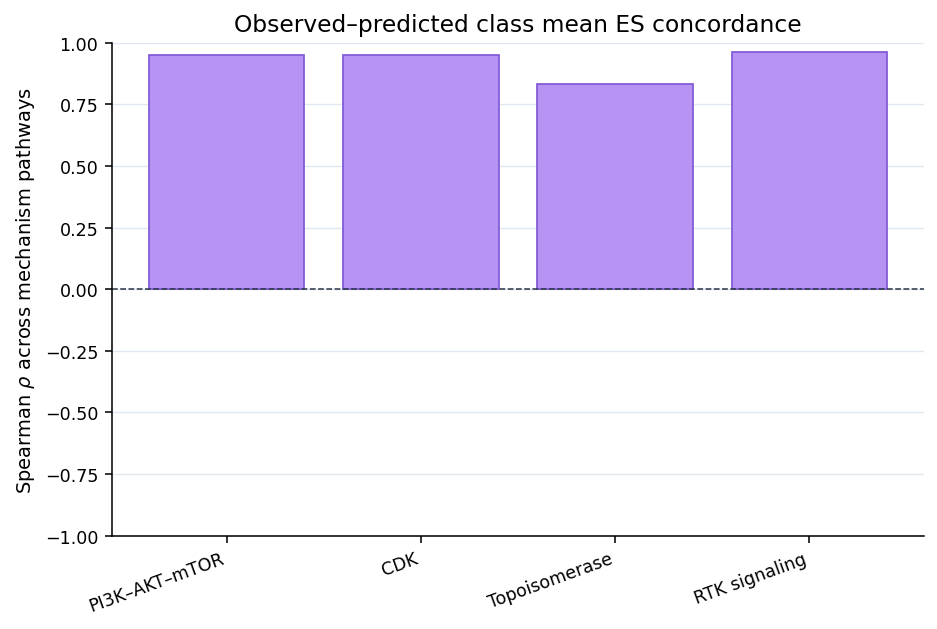

In [10]:
# ---------------------------------------------------------------------
# Supplement: class/pathway observed-versus-predicted agreement.
# ---------------------------------------------------------------------
correlation_rows = []
for drug_class, g in pooled_class_summary.groupby("drug_class"):
    wide = g.pivot(index="pathway", columns="source", values="mean_es").dropna()
    if len(wide) >= 3:
        rho = pd.Series(wide["observed"]).corr(pd.Series(wide["predicted"]), method="spearman")
    else:
        rho = np.nan
    correlation_rows.append({
        "drug_class": drug_class,
        "n_pathways": len(wide),
        "spearman_rho_across_pathways": rho,
    })

class_corr = pd.DataFrame(correlation_rows).set_index("drug_class").reindex(CLASS_ORDER).reset_index()
display(class_corr.round(4))
class_corr.to_csv(FIG / "Supplement_pooled_class_pathway_concordance.csv", index=False)

fig, ax = plt.subplots(figsize=(6.8, 4.6))
plot_data = class_corr.dropna(subset=["spearman_rho_across_pathways"]).copy()
ax.bar(
    [CLASS_LABELS[c] for c in plot_data["drug_class"]],
    plot_data["spearman_rho_across_pathways"],
    color="#B794F4",
    edgecolor=COLORS["predicted"],
    linewidth=0.9,
)
ax.axhline(0, color=COLORS["dark_gray"], linewidth=0.8, linestyle="--")
ax.set_ylim(-1, 1)
ax.set_ylabel("Spearman $\\rho$ across mechanism pathways")
ax.set_title("Observed–predicted class mean ES concordance")
lighten_axes_grid(ax)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
save_figure(fig, "Supplement_pooled_class_pathway_concordance")
plt.show()


## Optional supplementary individual-drug GSEA examples

The original individual-drug permutation-GSEA NES plots should be treated as supplementary illustrations. They are valuable because they show heterogeneity around the pooled class summary, but they should not be used as the primary class-level evidence.


In [11]:
# ---------------------------------------------------------------------
# Final manifest of generated publication figures and tables.
# ---------------------------------------------------------------------
generated = sorted(FIG.glob("*"))
print(f"Generated {len(generated)} files in {FIG}:")
for path in generated:
    print(path.name)


Generated 18 files in /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/NoRetraining_Analysis/analysis3_pathway_recovery_revised/figures_publication:
Figure4B_fold_summary.csv
Figure4B_hallmark_drug_split_concordance.pdf
Figure4B_hallmark_drug_split_concordance_publication.pdf
Figure4B_hallmark_drug_split_concordance_publication.png
Figure4C_fold_level_metric_values.csv
Figure4C_primary_replication_fold_level_metrics.pdf
Figure4C_primary_replication_fold_level_metrics.png
Figure4D_drug_fold_multiplicity_audit.csv
Figure4D_pooled_class_ES_bootstrap_summary.csv
Figure4D_pooled_class_mechanism_recovery.pdf
Figure4D_pooled_class_mechanism_recovery.png
Figure4D_pooled_drug_level_ES.csv
Supplement_matched_random_drug_null_gain_by_fold.pdf
Supplement_matched_random_drug_null_gain_by_fold.png
Supplement_null_gain_by_fold.csv
Supplement_pooled_class_pathway_concordance.csv
Supplement_pooled_class_pathway_concordance.pdf
Supplement_pooled_class